# Multi-Layer Module Stack — Scenario Pipeline Demo

Demonstrates the full **`Scenario`** class feature set using a hypothetical perovskite module stack:

> Glass / EVA front encapsulant / CsPbI₃ perovskite absorber / EVA back encapsulant / PET backsheet

**Features demonstrated:**
1. `addModule()` — module configuration (temperature model, racking) and named material layers
2. Sequential job chaining with `depends_on` — upstream results forwarded as kwargs at run time
3. Parallel branches — moisture ingress chain and absorber CE degradation computed independently
4. Module-based results — accessed via `s.results[module_name][job_name]`

**Pipeline:**

| Step | Function | Output | Depends on |
|------|----------|--------|------------|
| 1 | `spectral.poa_irradiance` | `poa` | — |
| 2 | `temperature.module` | `temp_mod` | `poa` |
| 3 | `rh_surface_job` | `rh_surface` | `temp_mod` |
| 4 | `front_encap_job` (EVA W001) | `rh_front_encap` | `temp_mod` |
| 5 | `back_encap_job` (EVA W001 + PET W017) | `rh_back_encap` | `temp_mod`, `rh_surface` |
| 6 | `perovskite_degradation_factor` (D046) | `ce_factor` | `poa` |

Steps 3–5 (moisture ingress) and step 6 (absorber CE factor) are **parallel branches**
that both depend only on the base thermal/irradiance computations (steps 1–2).


## 1. Imports and data

In [14]:
import os
import json
import tempfile
import numpy as np
import pandas as pd
import pvdeg
import matplotlib.pyplot as plt

REPO_ROOT = os.path.dirname(os.path.dirname(pvdeg.__file__))
TUTORIALS_DATA = os.path.join(REPO_ROOT, "tutorials", "data")

# Redirect all Scenario job folders to the system temp directory.
# Keeps the repo working directory free of pvd_job_* clutter.
pvdeg.config.SCENARIO_OUTPUT_PATH = tempfile.gettempdir()

# Zhao/Orooji parameters for the CsPbI₃ perovskite absorber layer
d046 = pvdeg.utilities.get_kinetics("D046")
skip_keys = {
    "DataEntryPerson",
    "DateEntered",
    "doi",
    "SourceTitle",
    "Authors",
    "Material",
    "EquationType",
}
print("D046 absorber parameters:")
for k, v in d046.items():
    if k not in skip_keys:
        print(f"  {k}: {v}")

D046 absorber parameters:
  Comments: Parameters for an uncapped CsPbI3 device from Zhao et al. 2022 (doi:10.1126/science.abn5679), as used in the degradation model of Orooji et al. 2026 (doi:10.1039/d6el00021e). Ea values were read from the Arrhenius plot (Fig. 3C of Zhao et al.). k0, A1, A2, B are the biexponential fit coefficients reported by Orooji et al. for the uncapped device; the Zhao supplementary does not tabulate these values. Users should re-fit k0, A1, A2, B to their own device data for more accurate quantitative predictions.
  Ea_fast: 0.248
  Ea_slow: 0.243
  k0_fast: 0.56
  k0_slow: 0.48
  A1: 0.25
  A2: 0.7
  B: 0.05
  gamma: 1.0
  I_ref: 1200.0


In [15]:
LOCATIONS = {
    "Golden, CO": ("psm4_golden.csv", "meta_golden.json"),
    "Miami, FL": ("psm4_miami.csv", "meta_miami.json"),
    "New York, NY": ("psm4_nyc.csv", "meta_nyc.json"),
}

all_weather, all_meta = {}, {}
for loc, (wf, mf) in LOCATIONS.items():
    df = pd.read_csv(
        os.path.join(TUTORIALS_DATA, wf),
        index_col=0,
        parse_dates=True,
    )
    df.index = df.index.map(lambda ts: ts.replace(year=2020))
    df = df.sort_index()
    with open(os.path.join(TUTORIALS_DATA, mf)) as _f:
        mt = json.load(_f)
    all_weather[loc], all_meta[loc] = df, mt
    print(f"  {loc}: {len(df)} rows  ({mt['latitude']:.2f}°N, {mt['longitude']:.2f}°E)")
# Single-location aliases used by the demonstration cells below
weather_df = all_weather["Golden, CO"]
meta = all_meta["Golden, CO"]

  Golden, CO: 8760 rows  (39.73°N, -105.18°E)
  Miami, FL: 8760 rows  (25.77°N, -80.18°E)
  New York, NY: 8760 rows  (40.65°N, -73.98°E)


## 2. Pipeline wrapper functions

The Scenario pipeline injects `weather_df` and `meta` into every function automatically.
Some `pvdeg.humidity` functions require individual weather columns (`rh_ambient`,
`temp_ambient`) rather than the full DataFrame. Three thin wrappers bridge this gap,
making those functions compatible with the pipeline while keeping the call site clean.


In [16]:
def rh_surface_job(weather_df, meta, temp_module):
    """Surface RH: scales ambient RH to module temperature.

    temp_module is injected via depends_on from the temp_mod job.
    """
    return pvdeg.humidity.surface_relative(
        rh_ambient=weather_df["relative_humidity"],
        temp_ambient=weather_df["temp_air"],
        temp_module=temp_module,
    )


def front_encap_job(weather_df, meta, temp_module):
    """Front encapsulant (glass-side) RH.

    Uses EVA W001 (Kempe 2006) defaults from pvdeg H2Opermeation database.
    Returns the diffusivity-weighted average moisture in the front EVA layer.
    """
    return pvdeg.humidity.front_encapsulant(
        rh_ambient=weather_df["relative_humidity"],
        temp_ambient=weather_df["temp_air"],
        temp_module=temp_module,
        # encapsulant="W001" is the default
    )


def back_encap_job(weather_df, meta, temp_module, rh_surface):
    """Back encapsulant (backsheet-side) RH.

    Moisture diffuses through the PET backsheet (W017), then into EVA (W001).
    Uses the quasi-steady-state permeation model (Kempe 2006).
    rh_surface is injected via depends_on from the rh_surface job.
    backsheet_thickness=0.3 mm and back_encap_thickness=0.46 mm are typical
    values for PET and EVA respectively (not stored in the W017/W001 DB entries).
    """
    return pvdeg.humidity.back_encapsulant_water_concentration(
        temp_module=temp_module,
        rh_surface=rh_surface,
        backsheet="W017",  # PET (Kempe, unpublished)
        encapsulant="W001",  # EVA (Kempe 2006)
        backsheet_thickness=0.3,  # mm — typical PET backsheet
        back_encap_thickness=0.46,  # mm — typical EVA encapsulant
        output="rh",
    )

## 3. Scenario: addModule and addJob

`addModule` registers the module-level configuration (temperature model, racking)
and named material layers. Here we load two materials from the `H2Opermeation` database:

- **`encapsulant`**: EVA W001 (Kempe 2006) — front and back encapsulant
- **`backsheet`**: PET W017 (Kempe, unpublished) — backsheet moisture barrier

In [17]:
s = pvdeg.Scenario(
    name="perov-module-stack",
    weather_data=weather_df,
    meta_data=meta,
)

# Register the module with temperature model settings and material layers
s.addModule(
    module_name="glass-eva-perov-eva-pet",
    racking="open_rack_glass_polymer",
    temperature_model="sapm",
    materials={
        "encapsulant": {
            "material_file": "H2Opermeation",
            "material_name": "W001",  # EVA (Kempe 2006)
        },
        "backsheet": {
            "material_file": "H2Opermeation",
            "material_name": "W017",  # PET (Kempe, unpublished)
        },
    },
)

# Job 1 — POA irradiance
s.addJob(func=pvdeg.spectral.poa_irradiance, name="poa")

# Job 2 — module temperature
s.addJob(
    func=pvdeg.temperature.module,
    name="temp_mod",
    depends_on={"poa": "poa"},
)

# Job 3 — surface RH (moisture ingress branch)
s.addJob(
    func=rh_surface_job,
    name="rh_surface",
    depends_on={"temp_module": "temp_mod"},
)

# Job 4 — front encapsulant RH (EVA W001, glass side)
s.addJob(
    func=front_encap_job,
    name="rh_front_encap",
    depends_on={"temp_module": "temp_mod"},
)

# Job 5 — back encapsulant RH (PET W017 → EVA W001, backsheet side)
s.addJob(
    func=back_encap_job,
    name="rh_back_encap",
    depends_on={"temp_module": "temp_mod", "rh_surface": "rh_surface"},
)

# Job 6 — absorber CE degradation factor (parallel to moisture chain)
s.addJob(
    func=(pvdeg.degradation.perovskite_degradation_factor, {"parameters": d046}),
    name="ce_factor",
    depends_on={"poa": "poa"},
)

print("Module layers:", list(s.modules[0]["material_params"].keys()))

Module layers: ['encapsulant', 'backsheet']


In [18]:
# Show the material parameters loaded from H2Opermeation for each layer
if "s" in globals():
    mat = s.modules[0]["material_params"]
elif "all_scenarios" in globals() and len(all_scenarios) > 0:
    sample_location = next(iter(all_scenarios.keys()))
    mat = all_scenarios[sample_location].modules[0]["material_params"]
else:
    raise RuntimeError("Run the Scenario setup cell first.")

for layer, params in mat.items():
    name = params.get("name", "?")
    alias = params.get("alias", "?")
    print(f"\n{layer.upper()} — {alias} ({name})")
    skip = {"name", "alias", "contributor", "source", "Fickian"}
    for k, v in params.items():
        if k not in skip:
            val = v["value"] if isinstance(v, dict) else v
            units = v.get("units", "") if isinstance(v, dict) else ""
            print(f"  {k:6s} = {val}  [{units}]")


ENCAPSULANT — EVA (Ethylene Vinyl Acetate)
  Ead    = 38.139966396438  []
  Do     = 2.31097881676966  []
  Eas    = 16.7286220351073  []
  So     = 1.81390701967487  []
  Eap    = 55.1578532714609  []
  Po     = 40728267519.3687  []

BACKSHEET — PET-2 (Polyethylene Terepthalate, ST504)
  Ead    = 49.1988088587438  []
  Do     = 1.43136116146877  []
  Eas    = 6.20764844309352  []
  So     = 0.106698381856152  []
  Eap    = 55.4064573018373  []
  Po     = 1319534666.90318  []


## 4. Run the pipeline

In [24]:
all_scenarios = {}
all_results = {}
module_name = "glass-eva-perov-eva-pet"

for loc in LOCATIONS:
    s_loc = pvdeg.Scenario(
        name=f"perov-module-stack-{loc.replace(', ', '-').replace(' ', '_')}",
        weather_data=all_weather[loc],
        meta_data=all_meta[loc],
    )

    # Register the module with temperature model settings and material layers
    s_loc.addModule(
        module_name=module_name,
        racking="open_rack_glass_polymer",
        temperature_model="sapm",
        materials={
            "encapsulant": {
                "material_file": "H2Opermeation",
                "material_name": "W001",  # EVA (Kempe 2006)
            },
            "backsheet": {
                "material_file": "H2Opermeation",
                "material_name": "W017",  # PET (Kempe, unpublished)
            },
        },
    )

    # Job 1 — POA irradiance
    s_loc.addJob(func=pvdeg.spectral.poa_irradiance, name="poa")

    # Job 2 — module temperature
    s_loc.addJob(
        func=pvdeg.temperature.module,
        name="temp_mod",
        depends_on={"poa": "poa"},
    )

    # Job 3 — surface RH (moisture ingress branch)
    s_loc.addJob(
        func=rh_surface_job,
        name="rh_surface",
        depends_on={"temp_module": "temp_mod"},
    )

    # Job 4 — front encapsulant RH (EVA W001, glass side)
    s_loc.addJob(
        func=front_encap_job,
        name="rh_front_encap",
        depends_on={"temp_module": "temp_mod"},
    )

    # Job 5 — back encapsulant RH (PET W017 -> EVA W001, backsheet side)
    s_loc.addJob(
        func=back_encap_job,
        name="rh_back_encap",
        depends_on={"temp_module": "temp_mod", "rh_surface": "rh_surface"},
    )

    # Job 6 — absorber CE degradation factor (parallel to moisture chain)
    s_loc.addJob(
        func=(pvdeg.degradation.perovskite_degradation_factor, {"parameters": d046}),
        name="ce_factor",
        depends_on={"poa": "poa"},
    )

    s_loc.run()

    res_loc = s_loc.results[module_name]
    all_scenarios[loc] = s_loc
    all_results[loc] = res_loc

# Default selection for downstream cells (user can change this)
selected_location = "Golden, CO"
res = all_results[selected_location]

The array surface_tilt angle was not provided, therefore the latitude of  39.7 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
The array surface_tilt angle was not provided, therefore the latitude of  25.8 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
The array surface_tilt angle was not provided, therefore the latitude of  40.6 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.


## 5. Results

This notebook now computes Scenario outputs for all three locations in `LOCATIONS`.
Use the variables in the next cell to choose a single location or overlay all locations:

- `PLOT_LOCATION = "Golden, CO"` (or `"Miami, FL"`, `"New York, NY"`)
- `OVERLAY_LOCATIONS = False` (set `True` to compare all on one figure)

| Panel | Quantity | Physical meaning |
|-------|----------|------------------|
| 1 | Module temperature [°C] | Thermal stress shared by all layers |
| 2 | Surface RH & front encapsulant RH [%] | Moisture at the glass/EVA interface |
| 3 | Back encapsulant RH [%] | Moisture arriving through the PET backsheet |

Note that the front encapsulant RH is lower than the surface RH because EVA moisture
solubility is temperature dependent. The back encapsulant RH is lower still due to the
PET backsheet moisture barrier.

The CE degradation factor (absorber optical decay) is covered in 06_scenario_perovskite_ey.ipynb.

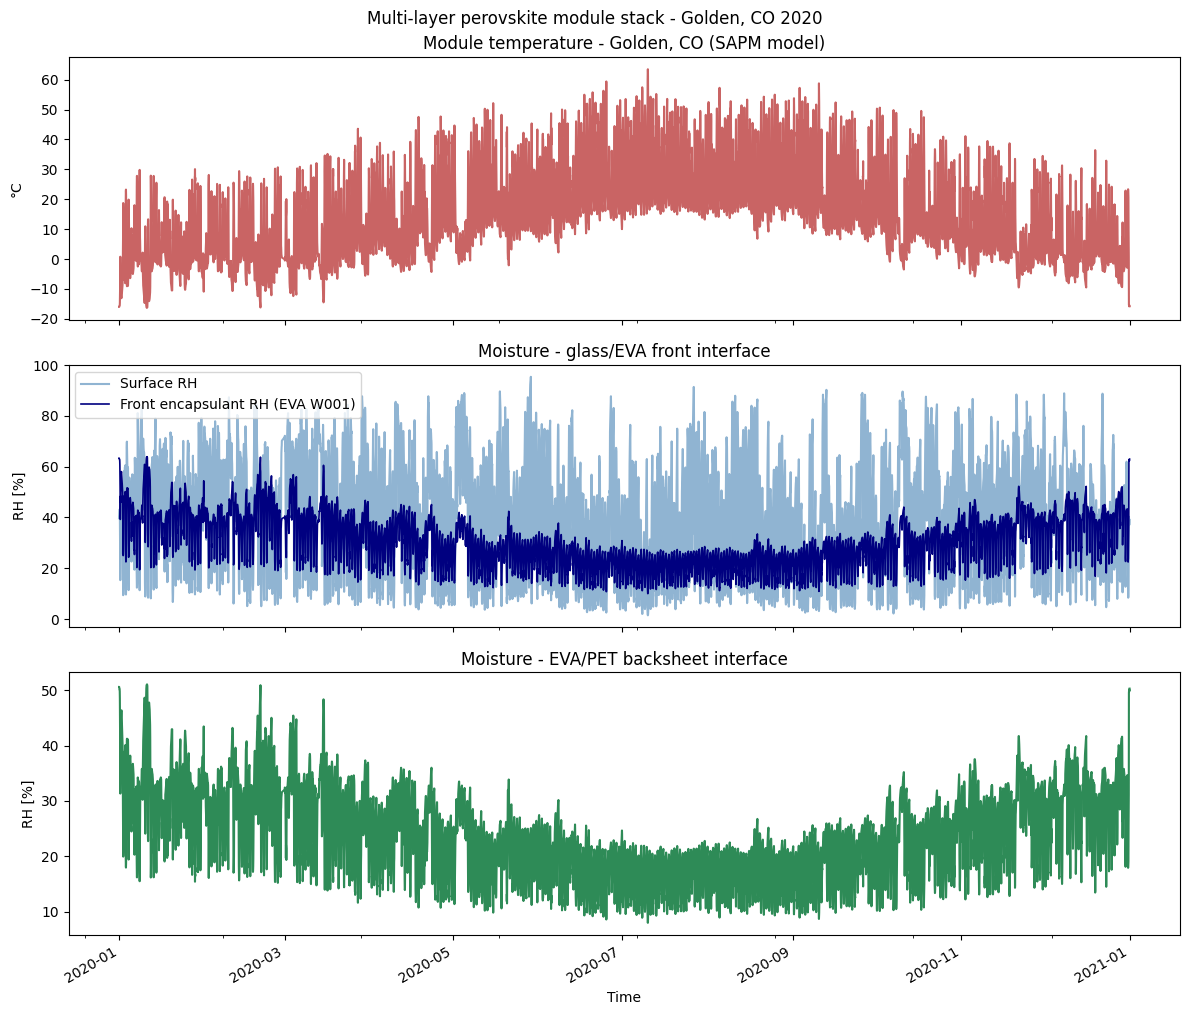

In [25]:
# Choose plotting mode
PLOT_LOCATION = "Golden, CO"
OVERLAY_LOCATIONS = False  # True overlays all locations on each panel

if OVERLAY_LOCATIONS:
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    for loc, res_loc in all_results.items():
        res_loc["temp_mod"].plot(ax=axes[0], linewidth=1.0, alpha=0.8, label=loc)
        res_loc["rh_surface"].plot(
            ax=axes[1],
            linewidth=0.8,
            alpha=0.45,
            linestyle="--",
            label=f"{loc} surface RH",
        )
        res_loc["rh_front_encap"].plot(
            ax=axes[1], linewidth=1.2, alpha=0.9, label=f"{loc} front encap RH"
        )
        res_loc["rh_back_encap"].plot(ax=axes[2], linewidth=1.0, alpha=0.8, label=loc)

    axes[0].set_ylabel("°C")
    axes[0].set_title("Module temperature comparison")
    axes[1].set_ylabel("RH [%]")
    axes[1].set_title("Surface and front encapsulant RH comparison")
    axes[2].set_ylabel("RH [%]")
    axes[2].set_title("Back encapsulant RH comparison")
    axes[2].set_xlabel("Time")

    axes[0].legend(ncol=3, fontsize=8)
    axes[1].legend(ncol=2, fontsize=7)
    axes[2].legend(ncol=3, fontsize=8)

    fig.tight_layout()
    fig.suptitle(
        "Multi-layer perovskite module stack - all locations (2020)",
        y=1.01,
        fontsize=12,
    )
else:
    if PLOT_LOCATION not in all_results:
        raise ValueError(f"PLOT_LOCATION must be one of {list(all_results.keys())}")

    res = all_results[PLOT_LOCATION]
    temp_mod = res["temp_mod"]
    rh_surface = res["rh_surface"]
    rh_front_encap = res["rh_front_encap"]
    rh_back_encap = res["rh_back_encap"]

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # Panel 1: module temperature
    temp_mod.plot(ax=axes[0], color="firebrick", alpha=0.7)
    axes[0].set_ylabel("°C")
    axes[0].set_title(f"Module temperature - {PLOT_LOCATION} (SAPM model)")

    # Panel 2: surface RH and front encapsulant RH
    rh_surface.plot(ax=axes[1], label="Surface RH", color="steelblue", alpha=0.6)
    rh_front_encap.plot(
        ax=axes[1], label="Front encapsulant RH (EVA W001)", color="navy", linewidth=1.2
    )
    axes[1].set_ylabel("RH [%]")
    axes[1].set_title("Moisture - glass/EVA front interface")
    axes[1].legend()

    # Panel 3: back encapsulant RH
    rh_back_encap.plot(ax=axes[2], color="seagreen")
    axes[2].set_ylabel("RH [%]")
    axes[2].set_title("Moisture - EVA/PET backsheet interface")
    axes[2].set_xlabel("Time")

    fig.tight_layout()
    fig.suptitle(
        f"Multi-layer perovskite module stack - {PLOT_LOCATION} 2020",
        y=1.01,
        fontsize=12,
    )

## 6. Acetic acid generation in EVA

This section focuses on acetic acid (HAc) generation in EVA, derived from the module
temperature and moisture ingress results.

- `acetic_acid_generation`: hourly HAc generation rate in EVA [ng/min/g]
- `acetic_acid_cumulative`: cumulative HAc produced in EVA [mg/g]

In [28]:
# Reuse selected location from results section
PLOT_LOCATION = globals().get("PLOT_LOCATION", "Golden, CO")
if PLOT_LOCATION not in all_results:
    raise ValueError(f"PLOT_LOCATION must be one of {list(all_results.keys())}")

res = all_results[PLOT_LOCATION]
temp_mod = res["temp_mod"]

# Acetic acid generation metrics in EVA
hac_rate = pvdeg.degradation.acetic_acid_generation(
    temp_module=temp_mod, encapsulant="AA002"
)
hac_cum = pvdeg.degradation.acetic_acid_cumulative(
    temp_module=temp_mod, encapsulant="AA002"
)

print(f"Selected location: {PLOT_LOCATION}")
print("HAc rate at start [ng/min/g]:", round(float(hac_rate.iloc[0]), 6))
print("HAc cumulative at 1000 h [mg/g]:", round(float(hac_cum.iloc[999]), 6))
print("HAc cumulative at 3000 h [mg/g]:", round(float(hac_cum.iloc[2999]), 6))

Selected location: Golden, CO
HAc rate at start [ng/min/g]: 8e-06
HAc cumulative at 1000 h [mg/g]: 2e-05
HAc cumulative at 3000 h [mg/g]: 0.00018


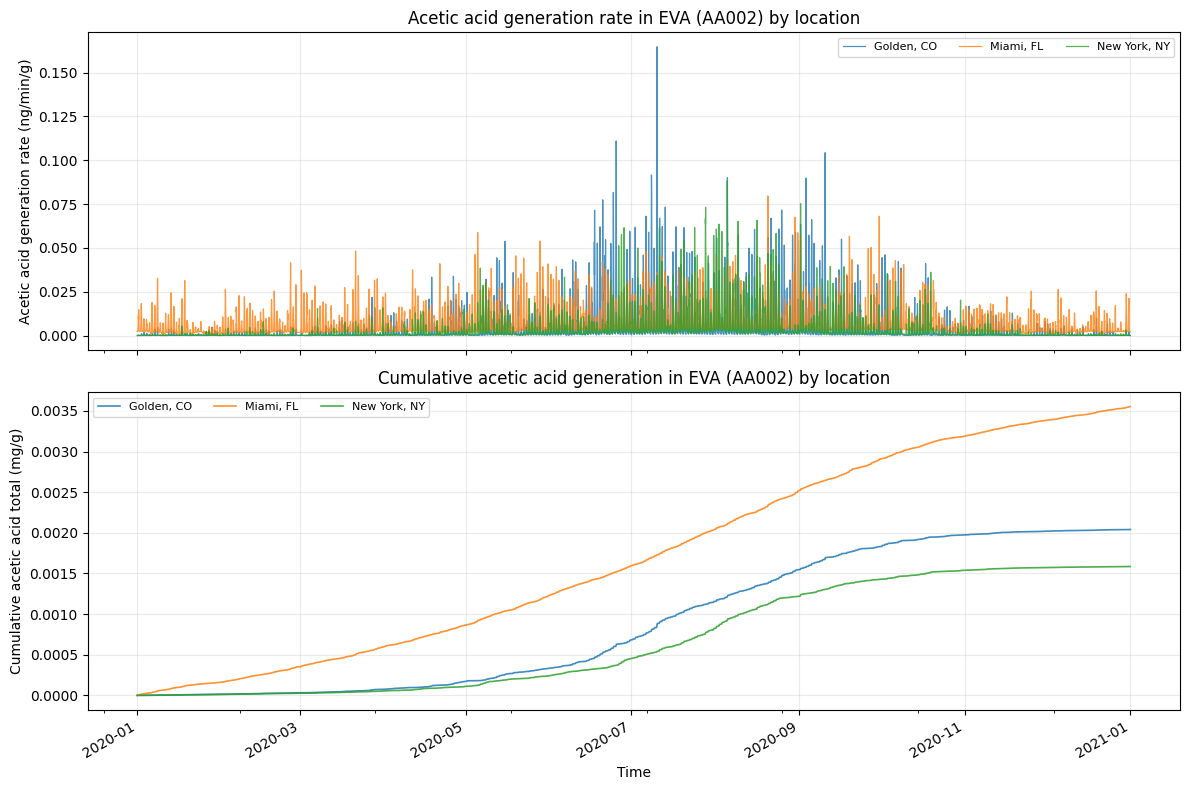

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for loc, res_loc in all_results.items():
    temp_loc = res_loc["temp_mod"]

    hac_rate_loc = pvdeg.degradation.acetic_acid_generation(
        temp_module=temp_loc, encapsulant="AA002"
    )
    hac_cum_loc = pvdeg.degradation.acetic_acid_cumulative(
        temp_module=temp_loc, encapsulant="AA002"
    )

    hac_rate_loc.plot(ax=axes[0], linewidth=0.9, alpha=0.8, label=loc)
    hac_cum_loc.plot(ax=axes[1], linewidth=1.2, alpha=0.85, label=loc)

axes[0].set_ylabel(
    "Acetic acid generation rate (ng/min/g)"
)  # nanograms of acetic acid produced per minute per gram of EVA
axes[0].set_title("Acetic acid generation rate in EVA (AA002) by location")
axes[1].set_ylabel("Cumulative acetic acid total (mg/g)")
axes[1].set_title("Cumulative acetic acid generation in EVA (AA002) by location")
axes[1].set_xlabel("Time")

axes[0].legend(ncol=3, fontsize=8)
axes[1].legend(ncol=3, fontsize=8)

for ax in axes:
    ax.grid(alpha=0.25)

fig.tight_layout()

---
## Summary and next steps

This notebook demonstrates the **`Scenario` pipeline architecture** applied to a hypothetical perovskite module stack. The key features demonstrated are `addModule()` (featuring racking, temperature modeling, and material layers), sequential job chaining using `depends_on`, permeation database lookup, and computing multiphysics outputs in the Scenario class using Scenario.run().

The three physical outputs computed are **independent stressors** on different layers of the module stack. They are not yet combined into a single module-level degradation metric.

Translating encapsulant moisture levels into an efficiency-loss contribution (e.g. delamination-induced optical coupling loss) requires additional modeling functionality not currently implemented in pvdeg. Once such models are available, the `Scenario` pipeline can chain them directly via `depends_on`, producing a true multi-mechanism module degradation index.

### See also

For perovskite absorber CE degradation, lifetime projections, and US state choropleth maps,
see **`06_scenario_perovskite_ey.ipynb`**.
